In [20]:
# ==========================================================
# LIBRERÍAS
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("default")

BASE_DIR = Path.cwd().parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"

In [21]:
municipios = pd.read_csv(
    "../data/processed/municipios_granada.csv"
)

print(municipios.head())
print(municipios["poblacion_2025"].describe())

   codigo_ine   municipio  poblacion_2025
0     18001.0       Agrón             247
1     18002.0  Alamedilla             518
2     18003.0    Albolote           19768
3     18004.0    Albondón             703
4     18006.0     Albuñol            7388
count       175.000000
mean      10772.777143
std       73282.678229
min         139.000000
25%         622.500000
50%        1218.000000
75%        4040.500000
max      942618.000000
Name: poblacion_2025, dtype: float64


In [22]:
# ==========================================================
# CARGA DATASET MAESTRO
# ==========================================================

df = pd.read_csv(
    DATA_PROCESSED / "dataset_maestro_granada_v1.csv"
)

print(df.shape)

df.head()

(128, 11)


,codigo_ine,municipio,poblacion_2025,n_poligonos_residenciales,superficie_residencial_m2,superficie_residencial_ha,superficie_media_poligono_m2,superficie_mediana_poligono_m2,superficie_max_poligono_m2,perimetro_total_m,suelo_residencial_m2_por_hab
0,18905,"Gabias, Las",23584,1,3.682035e+06,368.203480,3.682035e+06,3.682035e+06,3.682035e+06,40983.790385,156.124271
1,18089,Guadix,18881,7,3.460928e+06,346.092770,4.944182e+05,1.185983e+05,2.848796e+06,43493.539742,183.302140
2,18022,Atarfe,20914,1,3.364040e+06,336.403955,3.364040e+06,3.364040e+06,3.364040e+06,37294.919233,160.851083
3,18029,Benamaurel,2235,9,3.295178e+06,329.517829,3.661309e+05,1.089552e+05,1.376323e+06,32558.922141,1474.352704
4,18003,Albolote,19768,1,2.949836e+06,294.983553,2.949836e+06,2.949836e+06,2.949836e+06,42092.590074,149.222761


In [23]:
# ==========================================================
# INFORMACIÓN GENERAL
# ==========================================================

df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   codigo_ine                      128 non-null    int64  
 1   municipio                       128 non-null    object 
 2   poblacion_2025                  128 non-null    int64  
 3   n_poligonos_residenciales       128 non-null    int64  
 4   superficie_residencial_m2       128 non-null    float64
 5   superficie_residencial_ha       128 non-null    float64
 6   superficie_media_poligono_m2    128 non-null    float64
 7   superficie_mediana_poligono_m2  128 non-null    float64
 8   superficie_max_poligono_m2      128 non-null    float64
 9   perimetro_total_m               128 non-null    float64
 10  suelo_residencial_m2_por_hab    128 non-null    float64
dtypes: float64(7), int64(3), object(1)
memory usage: 11.1+ KB


,codigo_ine,municipio,poblacion_2025,n_poligonos_residenciales,superficie_residencial_m2,superficie_residencial_ha,superficie_media_poligono_m2,superficie_mediana_poligono_m2,superficie_max_poligono_m2,perimetro_total_m,suelo_residencial_m2_por_hab
count,128.000000,128,128.000000,128.000000,1.280000e+02,128.000000,1.280000e+02,1.280000e+02,1.280000e+02,128.000000,128.000000
unique,NaN,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"Gabias, Las",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,18154.695312,NaN,4361.789062,2.695312,6.603166e+05,66.031664,3.899484e+05,3.608302e+05,5.402039e+05,12582.840865,251.216743
std,227.088541,NaN,7679.283618,3.018470,7.783636e+05,77.836360,5.996364e+05,6.080719e+05,6.641787e+05,11409.306398,172.447139
min,18001.000000,NaN,203.000000,1.000000,2.672803e+04,2.672803,1.078619e+04,3.237328e+03,2.233845e+04,1185.382465,11.296156
25%,18045.750000,NaN,674.500000,1.000000,2.018424e+05,20.184236,9.821958e+04,6.343438e+04,1.637998e+05,4574.566409,145.161183
50%,18098.000000,NaN,1387.500000,1.000000,3.642070e+05,36.420695,1.851634e+05,1.399478e+05,2.685876e+05,8328.062894,210.454256
75%,18150.250000,NaN,3901.250000,3.000000,7.357848e+05,73.578482,3.727848e+05,3.608513e+05,6.314659e+05,15706.375735,315.595142


In [24]:
# ==========================================================
# NULOS
# ==========================================================

df.isnull().sum()

codigo_ine                        0
municipio                         0
poblacion_2025                    0
n_poligonos_residenciales         0
superficie_residencial_m2         0
superficie_residencial_ha         0
superficie_media_poligono_m2      0
superficie_mediana_poligono_m2    0
superficie_max_poligono_m2        0
perimetro_total_m                 0
suelo_residencial_m2_por_hab      0
dtype: int64

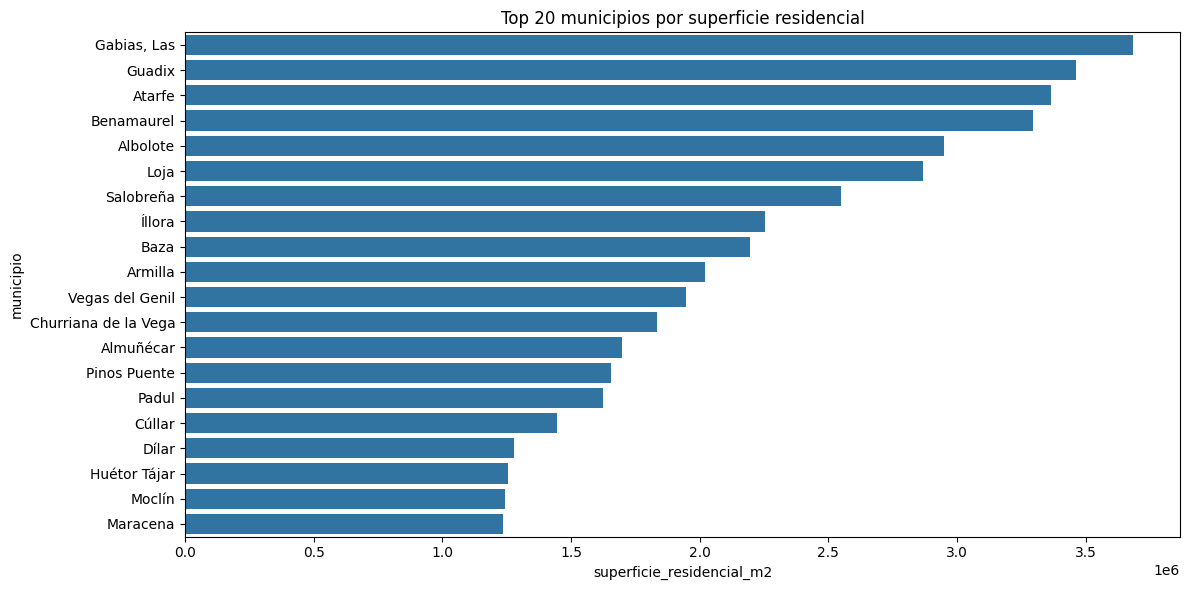

In [25]:
# ==========================================================
# TOP SUPERFICIE RESIDENCIAL
# ==========================================================

top_sup = (
    df
    .sort_values(
        "superficie_residencial_m2",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sup,
    x="superficie_residencial_m2",
    y="municipio"
)

plt.title(
    "Top 20 municipios por superficie residencial"
)

plt.tight_layout()
plt.show()

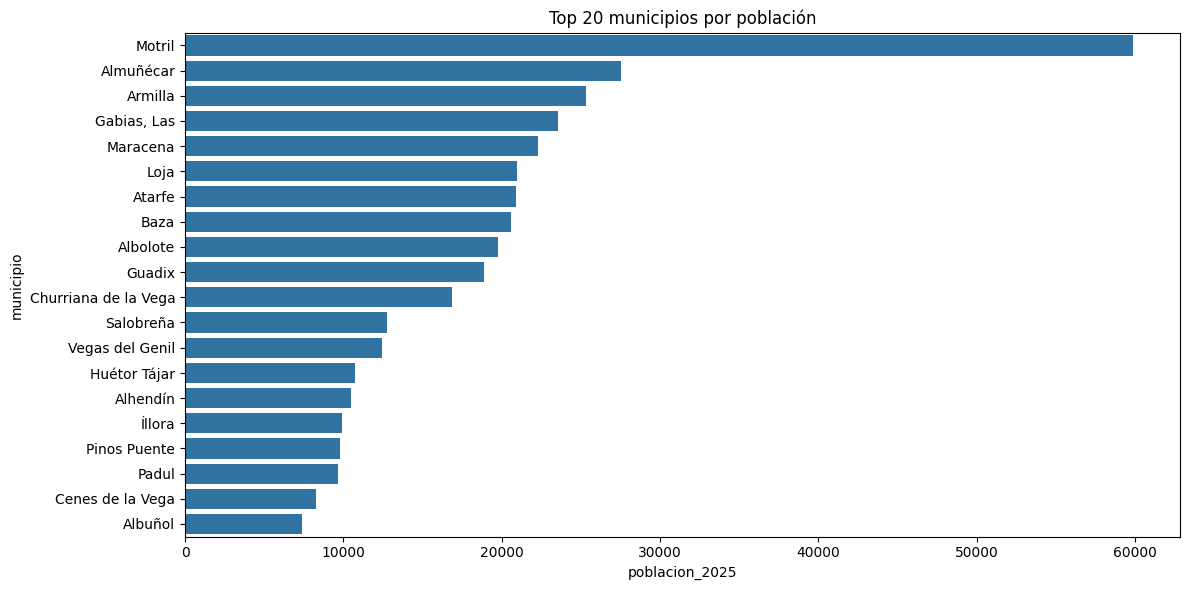

In [26]:
# ==========================================================
# TOP POBLACIÓN
# ==========================================================

top_pob = (
    df
    .sort_values(
        "poblacion_2025",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_pob,
    x="poblacion_2025",
    y="municipio"
)

plt.title(
    "Top 20 municipios por población"
)

plt.tight_layout()
plt.show()

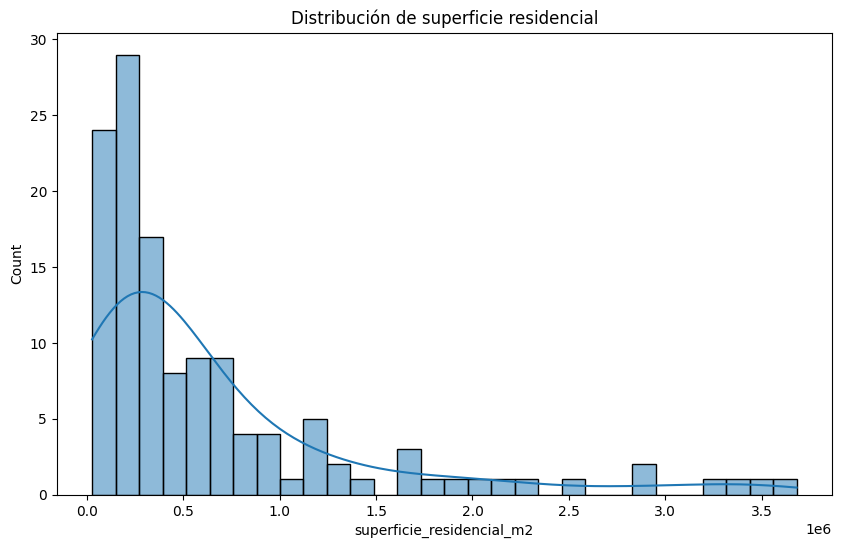

In [27]:
# ==========================================================
# DISTRIBUCIÓN SUPERFICIE
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["superficie_residencial_m2"],
    bins=30,
    kde=True
)

plt.title(
    "Distribución de superficie residencial"
)

plt.show()

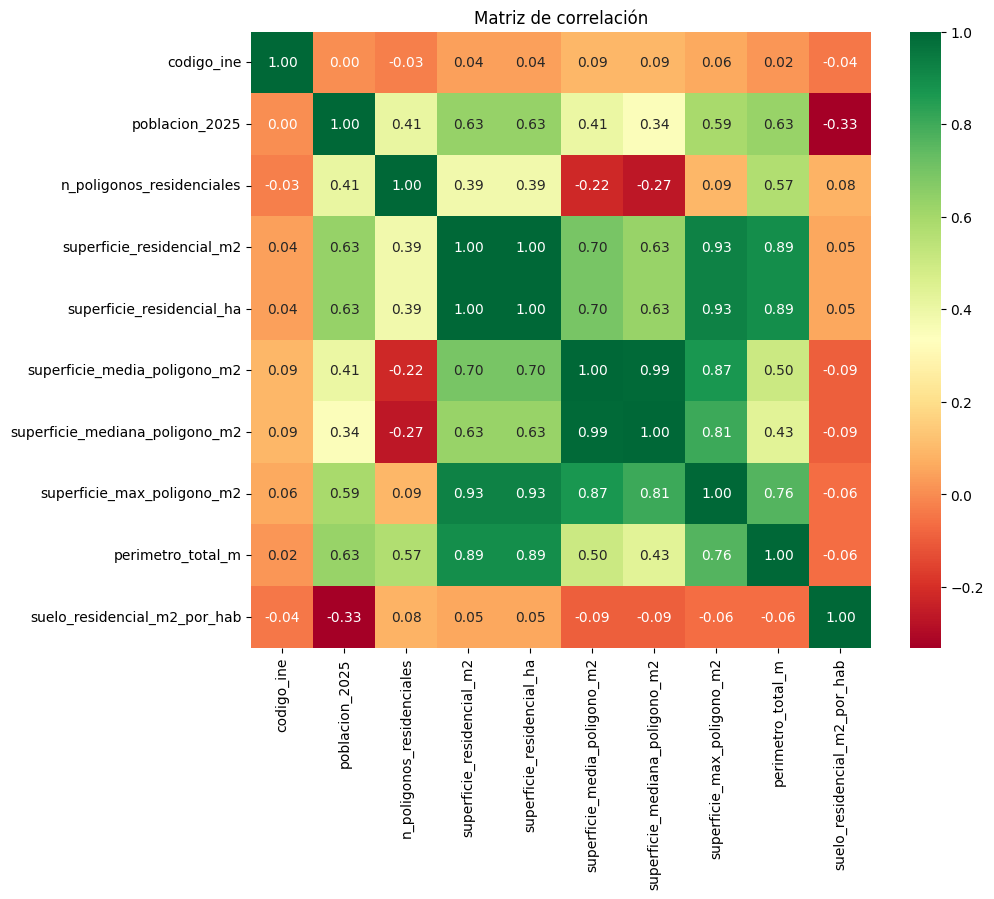

In [28]:
# ==========================================================
# CORRELACIONES
# ==========================================================

numericas = df.select_dtypes(
    include=["int64","float64"]
)

corr = numericas.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title(
    "Matriz de correlación"
)

plt.show()

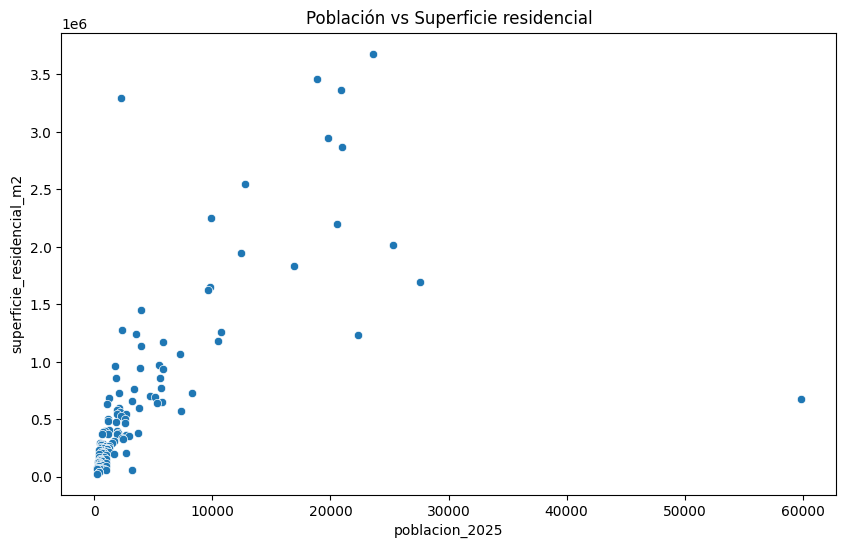

In [29]:
# ==========================================================
# POBLACIÓN VS SUELO
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="poblacion_2025",
    y="superficie_residencial_m2"
)

plt.title(
    "Población vs Superficie residencial"
)

plt.show()